In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. CHARGEMENT DES DONNÉES
df = pd.read_csv('../data/clean_data.csv', encoding='ISO-8859-1')

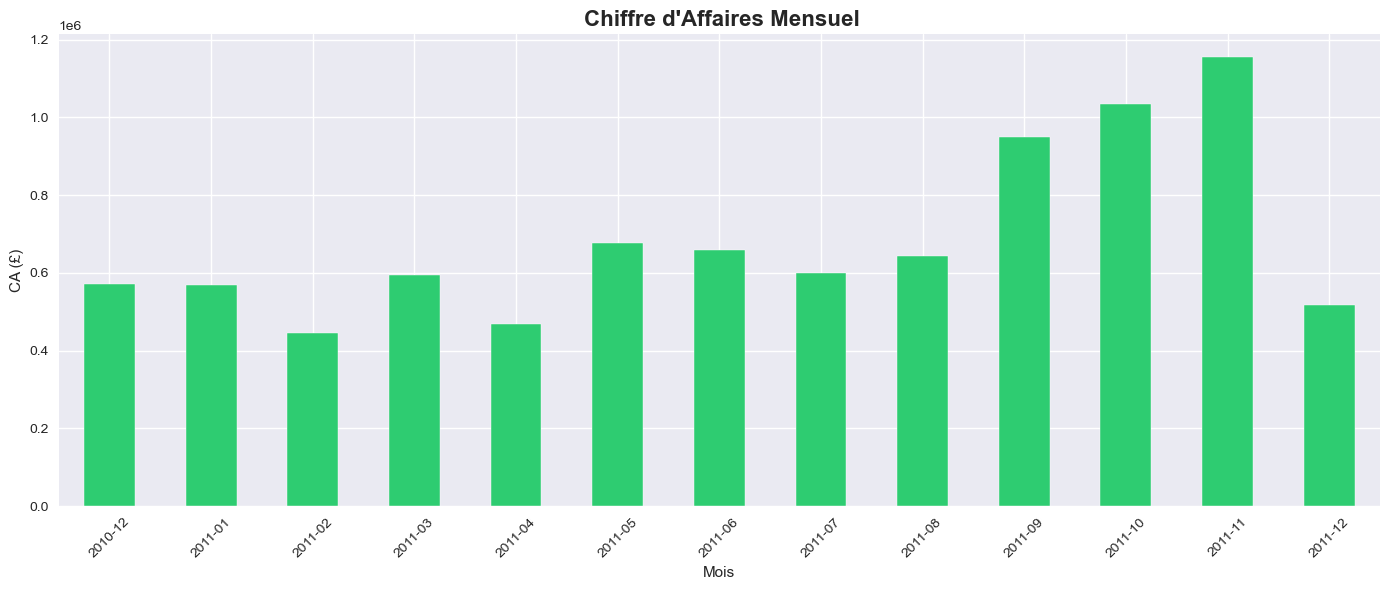


 CA mensuel moyen : £683,631.45
 Meilleur mois   : 2011-11 → £1,156,205.61
 Pire mois       : 2011-02 → £446,084.92


In [9]:
# NOTEBOOK : KPIs VENTES

# 1. CHIFFRE D'AFFAIRES PAR MOIS
ca_mensuel = df.groupby('Mois')['CA'].sum()

plt.figure(figsize=(14, 6))
ca_mensuel.plot(kind='bar', color='#2ecc71', edgecolor='white')
plt.title(' Chiffre d\'Affaires Mensuel', fontsize=16, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('CA (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n CA mensuel moyen : £{ca_mensuel.mean():,.2f}")
print(f" Meilleur mois   : {ca_mensuel.idxmax()} → £{ca_mensuel.max():,.2f}")
print(f" Pire mois       : {ca_mensuel.idxmin()} → £{ca_mensuel.min():,.2f}")


 PANIER MOYEN :
Moyenne  : £479.56
Médiane  : £302.57
Min      : £0.38
Max      : £168,469.60


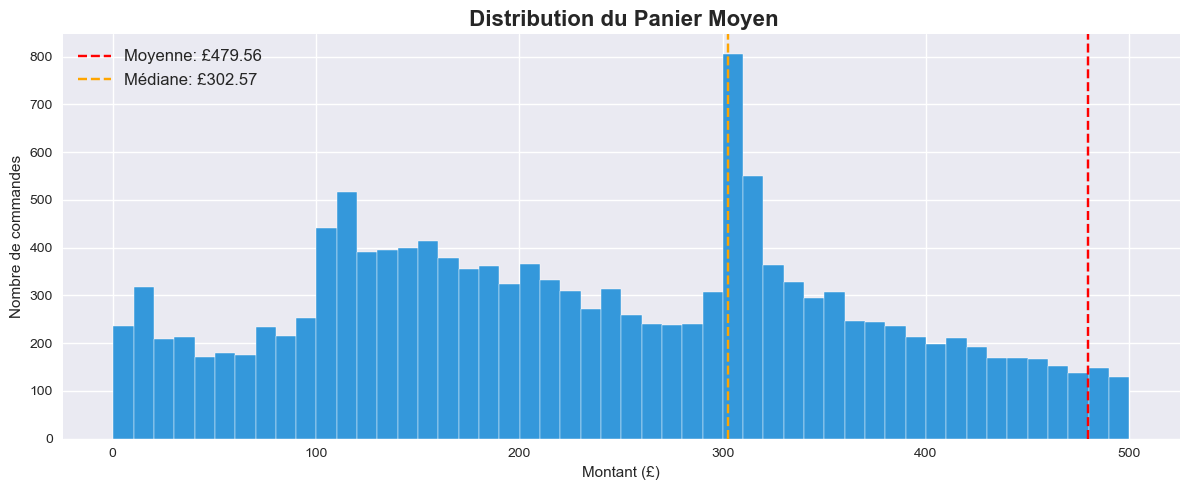

In [12]:
# 2. PANIER MOYEN (AOV)
panier_par_commande = df.groupby('InvoiceNo')['CA'].sum()

panier_moyen = panier_par_commande.mean()
panier_median = panier_par_commande.median()

print(" PANIER MOYEN :")
print(f"Moyenne  : £{panier_moyen:,.2f}")
print(f"Médiane  : £{panier_median:,.2f}")
print(f"Min      : £{panier_par_commande.min():,.2f}")
print(f"Max      : £{panier_par_commande.max():,.2f}")

# Visualisation
plt.figure(figsize=(12, 5))
panier_par_commande[panier_par_commande < 500].hist(bins=50, color='#3498db', edgecolor='white')
plt.axvline(panier_moyen, color='red', linestyle='--', label=f'Moyenne: £{panier_moyen:.2f}')
plt.axvline(panier_median, color='orange', linestyle='--', label=f'Médiane: £{panier_median:.2f}')
plt.title(' Distribution du Panier Moyen', fontsize=16, fontweight='bold')
plt.xlabel('Montant (£)')
plt.ylabel('Nombre de commandes')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


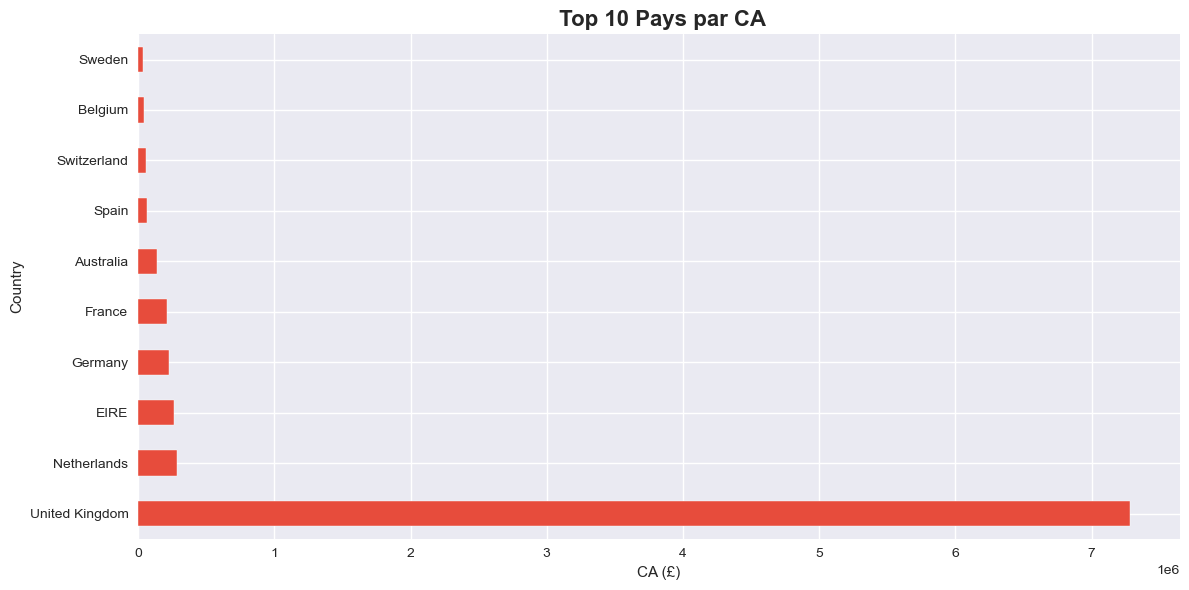

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: CA, dtype: float64


In [4]:
# 3. TOP 10 PAYS PAR CA
ca_pays = df.groupby('Country')['CA'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ca_pays.plot(kind='barh', color='#e74c3c', edgecolor='white')
plt.title(' Top 10 Pays par CA', fontsize=16, fontweight='bold')
plt.xlabel('CA (£)')
plt.tight_layout()
plt.show()

print(ca_pays)


 TOP 10 PRODUITS PAR CA
                                    Quantite         CA  Commandes
Description                                                       
PAPER CRAFT , LITTLE BIRDIE            80995  168469.60          1
REGENCY CAKESTAND 3 TIER               12374  142264.75       1703
WHITE HANGING HEART T-LIGHT HOLDER     36706  100392.10       1971
JUMBO BAG RED RETROSPOT                46078   85040.54       1600
MEDIUM CERAMIC TOP STORAGE JAR         77916   81416.73        195
POSTAGE                                 3120   77803.96       1099
PARTY BUNTING                          15279   68785.23       1379
ASSORTED COLOUR BIRD ORNAMENT          35263   56413.03       1375
Manual                                  6933   53419.93        253
RABBIT NIGHT LIGHT                     27153   51251.24        801


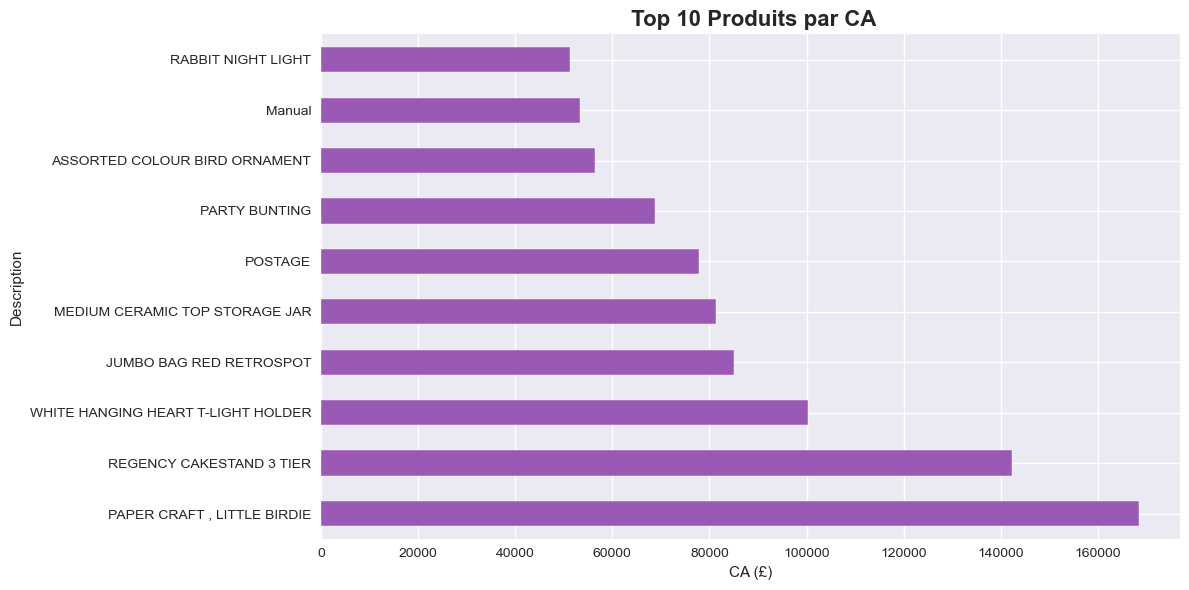

In [13]:
# 4. TOP 10 PRODUITS LES PLUS VENDUS
top_produits = df.groupby('Description').agg(
    Quantite=('Quantity', 'sum'),
    CA=('CA', 'sum'),
    Commandes=('InvoiceNo', 'nunique')
).sort_values('CA', ascending=False).head(10)

print(" TOP 10 PRODUITS PAR CA")
print("=" * 60)
print(top_produits)

plt.figure(figsize=(12, 6))
top_produits['CA'].plot(kind='barh', color='#9b59b6', edgecolor='white')
plt.title(' Top 10 Produits par CA', fontsize=16, fontweight='bold')
plt.xlabel('CA (£)')
plt.tight_layout()
plt.show()


 TOP 10 PRODUITS PAR CA
                                    Quantite         CA  Commandes
Description                                                       
PAPER CRAFT , LITTLE BIRDIE            80995  168469.60          1
REGENCY CAKESTAND 3 TIER               12374  142264.75       1703
WHITE HANGING HEART T-LIGHT HOLDER     36706  100392.10       1971
JUMBO BAG RED RETROSPOT                46078   85040.54       1600
MEDIUM CERAMIC TOP STORAGE JAR         77916   81416.73        195
POSTAGE                                 3120   77803.96       1099
PARTY BUNTING                          15279   68785.23       1379
ASSORTED COLOUR BIRD ORNAMENT          35263   56413.03       1375
Manual                                  6933   53419.93        253
RABBIT NIGHT LIGHT                     27153   51251.24        801


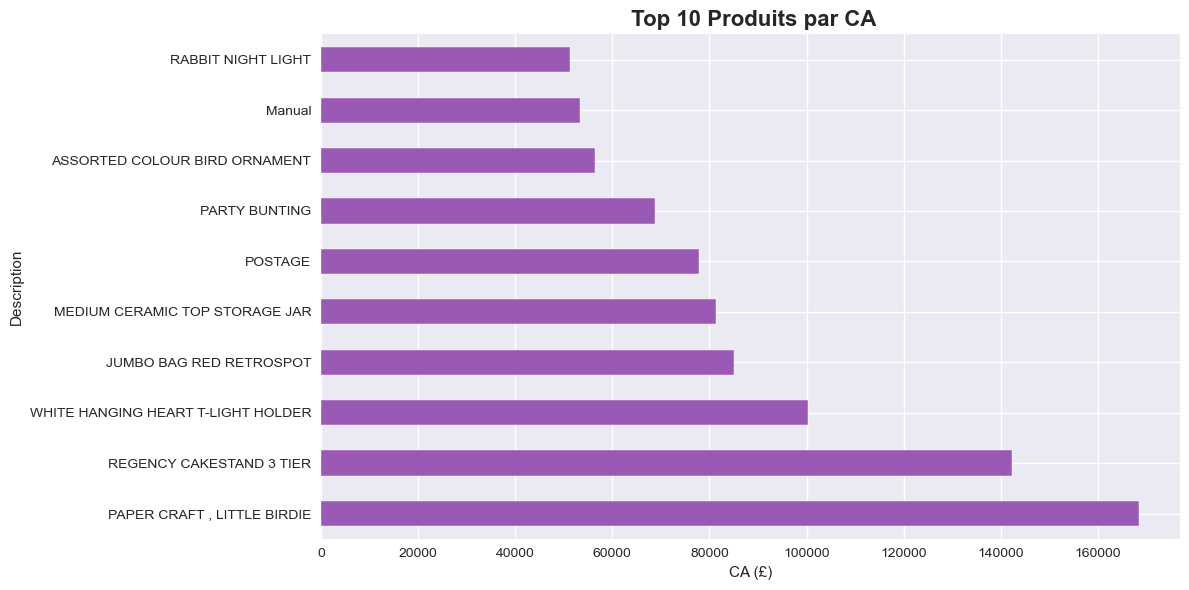

In [14]:
# 4. TOP 10 PRODUITS LES PLUS VENDUS
top_produits = df.groupby('Description').agg(
    Quantite=('Quantity', 'sum'),
    CA=('CA', 'sum'),
    Commandes=('InvoiceNo', 'nunique')
).sort_values('CA', ascending=False).head(10)

print(" TOP 10 PRODUITS PAR CA")
print("=" * 60)
print(top_produits)

plt.figure(figsize=(12, 6))
top_produits['CA'].plot(kind='barh', color='#9b59b6', edgecolor='white')
plt.title(' Top 10 Produits par CA', fontsize=16, fontweight='bold')
plt.xlabel('CA (£)')
plt.tight_layout()
plt.show()


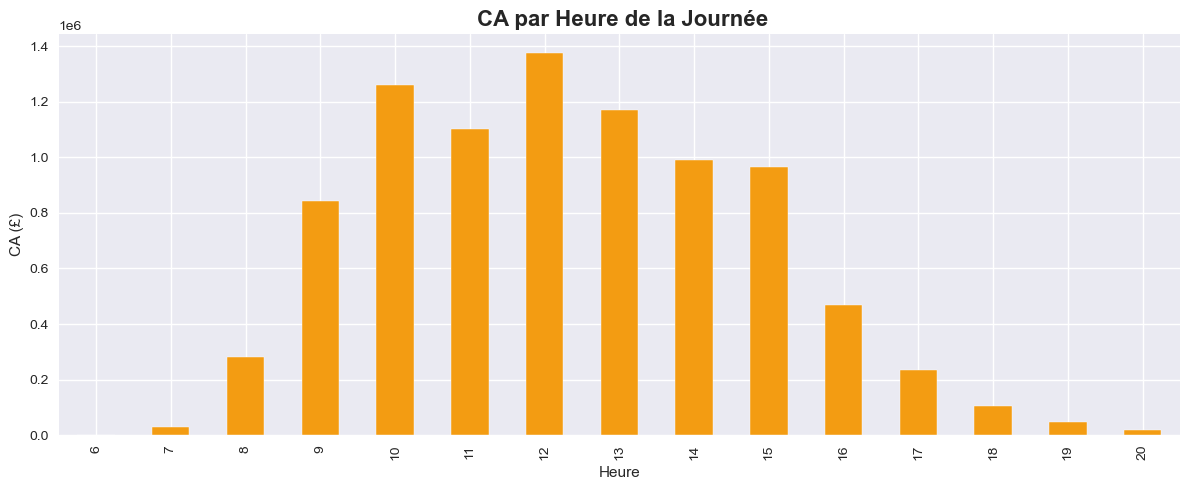


 Heure la plus rentable : 12h → £1,373,695.39


In [16]:
# 5. VENTES PAR HEURE DE LA JOURNÉE
ca_heure = df.groupby('Heure')['CA'].sum()

plt.figure(figsize=(12, 5))
ca_heure.plot(kind='bar', color='#f39c12', edgecolor='white')
plt.title(' CA par Heure de la Journée', fontsize=16, fontweight='bold')
plt.xlabel('Heure')
plt.ylabel('CA (£)')
plt.tight_layout()
plt.show()

print(f"\n Heure la plus rentable : {ca_heure.idxmax()}h → £{ca_heure.max():,.2f}")


In [17]:
# 6. TABLEAU RÉCAPITULATIF KPI 1

print(" RÉCAPITULATIF KPI 1 - VENTES")
print(f" CA Total           : £{df['CA'].sum():,.2f}")
print(f" CA Mensuel Moyen   : £{ca_mensuel.mean():,.2f}")
print(f" Panier Moyen       : £{panier_moyen:,.2f}")
print(f" Panier Médian      : £{panier_median:,.2f}")
print(f" Nb Commandes       : {df['InvoiceNo'].nunique()}")
print(f" Nb Clients         : {df['CustomerID'].nunique()}")
print(f" Meilleur mois      : {ca_mensuel.idxmax()}")
print(f" Meilleure heure    : {ca_heure.idxmax()}h")
print(f" Meilleur pays      : {ca_pays.index[0]}")


 RÉCAPITULATIF KPI 1 - VENTES
 CA Total           : £8,887,208.89
 CA Mensuel Moyen   : £683,631.45
 Panier Moyen       : £479.56
 Panier Médian      : £302.57
 Nb Commandes       : 18532
 Nb Clients         : 4338
 Meilleur mois      : 2011-11
 Meilleure heure    : 12h
 Meilleur pays      : United Kingdom
